# Fase 5b — Enriquecimiento de features para clustering

**Proyecto Final — Gestión de Datos (UAX) · 3º Ingeniería Matemática**

## Motivación

El análisis del notebook `05_pca_clustering.ipynb` original reveló que las features usadas (`ingresos_t`, `ticket_medio`, `frecuencia_t`, `margen_t`, `tasa_devolucion`) **no aportan dimensionalidad real** al espacio de clientes:

- `margen_t` ≈ 0.40 para el 75% de los clientes (margen del producto, no del cliente)
- `frecuencia_t` ≈ 0.015 v/mes para el 75% (1 sola compra)
- `ticket_medio` ≡ `ingresos_t` cuando `num_ventas = 1`
- `tasa_devolucion` = 0 para el 75% de clientes

Resultado: el PCA atribuía **97.1% de la varianza a PC1** (esencialmente `ingresos_t`), y el K-Means se reducía a partir el rango de ingresos en buckets.

## Solución

Enriquecemos `cltv_resultados.csv` con features que sí tienen varianza real, calculadas directamente desde el DWH:

| Feature | Cálculo | Por qué aporta varianza |
|---|---|---|
| `n_productos_distintos` | COUNT(DISTINCT product_id) por cliente | Mide diversidad de catálogo |
| `n_tiendas_distintas`   | COUNT(DISTINCT store_id) por cliente   | Mide movilidad geográfica |
| `n_categorias_distintas`| COUNT(DISTINCT category) por cliente   | Mide variedad de consumo  |
| `lineas_por_venta`      | num_lineas / num_ventas                | Tamaño medio de la cesta |
| `log_ingresos`          | log1p(ingresos_t)                      | Comprime cola larga       |
| `log_ticket_medio`      | log1p(ticket_medio)                    | Comprime cola larga       |

Tras este enriquecimiento, el clustering tendrá un espacio mucho más rico y los segmentos serán accionables.

---
## 1. Imports y conexión al DWH

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy as sa
from sqlalchemy import text
from IPython.display import display

warnings.filterwarnings('ignore')

# ── CONEXION AL DWH ─────────────────────────────────────────────────────
HOST, PORT, DB_NAME, USER, PASSWORD = 'localhost', 5432, 'Proyecto_final', 'admin', 'admin'
engine = sa.create_engine(f'postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}')

with engine.connect() as conn:
    n_fact = conn.execute(text('SELECT COUNT(*) FROM dwh.fact_sales')).scalar()
print(f'Conexión OK. fact_sales: {n_fact:,} filas')

Conexión OK. fact_sales: 42,555 filas


---
## 2. Calcular features de diversidad desde el DWH

Una sola query agrupada por cliente que cruza `fact_sales` con `dim_product` para obtener:
- número de productos distintos
- número de tiendas distintas
- número de categorías distintas
- líneas por venta (cesta media)

In [2]:
query_div = """
SELECT
    f.customer_id,
    COUNT(DISTINCT f.product_id)            AS n_productos_distintos,
    COUNT(DISTINCT f.store_id)              AS n_tiendas_distintas,
    COUNT(DISTINCT p.category)              AS n_categorias_distintas,
    COUNT(f.sale_item_id)::float
        / NULLIF(COUNT(DISTINCT f.sale_id),0) AS lineas_por_venta
FROM dwh.fact_sales f
JOIN dwh.dim_product p USING (product_id)
GROUP BY f.customer_id
ORDER BY f.customer_id
"""

with engine.connect() as conn:
    df_div = pd.read_sql(text(query_div), conn)

print(f'Filas: {len(df_div):,}')
print()
display(df_div.describe().round(3))

Filas: 5,750



,customer_id,n_productos_distintos,n_tiendas_distintas,n_categorias_distintas,lineas_por_venta
count,5750.000,5750.000,5750.000,5750.000,5750.000
mean,2877.239,4.944,2.513,1.725,1.196
std,1660.419,10.340,3.980,1.882,0.515
min,1.000,1.000,1.000,1.000,1.000
25%,1440.250,1.000,1.000,1.000,1.000
50%,2877.500,1.000,1.000,1.000,1.000
75%,4314.750,1.000,1.000,1.000,1.000
max,5752.000,43.000,19.000,7.000,3.429


**Comprobación crítica:** queremos ver que estas features SÍ tienen varianza real (que P25, P50 y P75 son distintos).

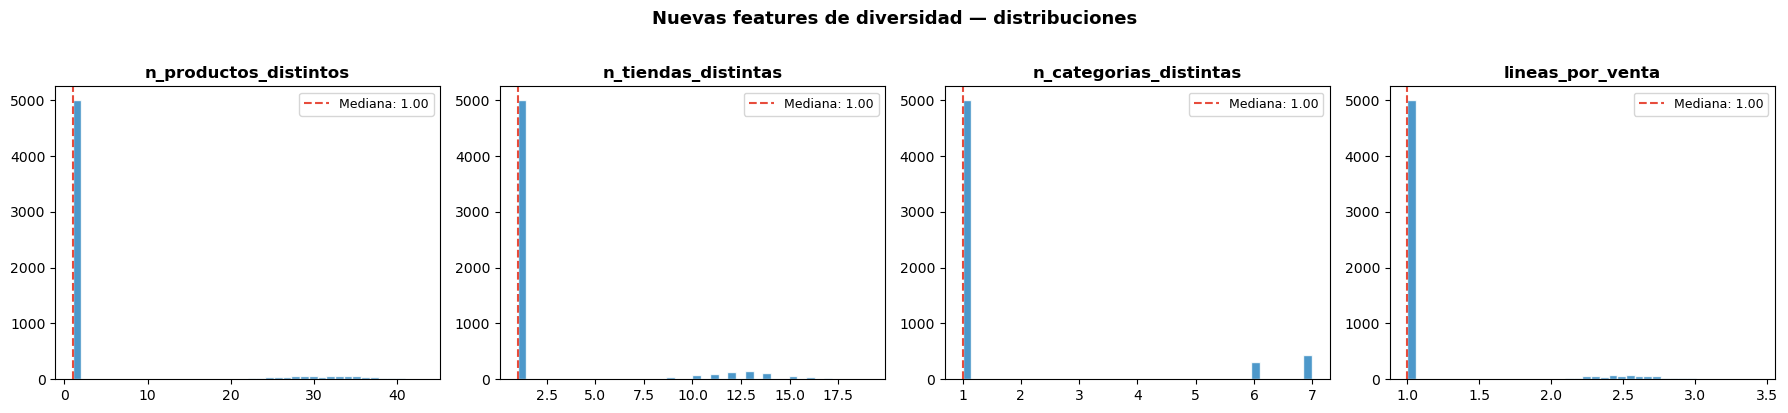

In [3]:
# Histogramas de las nuevas features
feats = ['n_productos_distintos', 'n_tiendas_distintas',
         'n_categorias_distintas', 'lineas_por_venta']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, f in zip(axes, feats):
    ax.hist(df_div[f], bins=40, color='#2E86C1', edgecolor='white', alpha=0.85)
    ax.set_title(f, fontweight='bold')
    ax.axvline(df_div[f].median(), color='#E74C3C', linestyle='--', linewidth=1.5,
               label=f'Mediana: {df_div[f].median():.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Nuevas features de diversidad — distribuciones',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/04b_diversidad_distribuciones.png', dpi=130, bbox_inches='tight')
plt.show()
plt.close()

---
## 3. Cargar `cltv_resultados.csv` y mergear las nuevas features

In [4]:
df = pd.read_csv('cltv_resultados.csv')
print(f'cltv_resultados.csv original: {df.shape}')
print(f'Columnas: {list(df.columns)}')

cltv_resultados.csv original: (5750, 24)
Columnas: ['customer_id', 'full_name', 'first_purchase_date', 'last_purchase_date', 'customer_age_days', 'ingresos_t', 'margen_total', 'margen_t', 'num_ventas', 'num_lineas', 'r_t', 'frecuencia_t', 'ticket_medio', 'cltv', 'segmento_cltv', 'dias_sin_compra', 'churn_proxy', 'num_devoluciones', 'tasa_devolucion', 'R_score', 'F_score', 'M_score', 'rfm_score', 'segmento_rfm']


In [5]:
# Merge
df_aug = df.merge(df_div, on='customer_id', how='left')

# Imputar a 0 las features de diversidad si NaN (cliente sin compras — no debería pasar pero por seguridad)
for f in feats:
    df_aug[f] = df_aug[f].fillna(0)

print(f'cltv_resultados augmentado: {df_aug.shape}')
print(f'Nulos tras merge: {df_aug[feats].isnull().sum().to_dict()}')

cltv_resultados augmentado: (5750, 28)
Nulos tras merge: {'n_productos_distintos': 0, 'n_tiendas_distintas': 0, 'n_categorias_distintas': 0, 'lineas_por_venta': 0}


---
## 4. Añadir transformaciones logarítmicas

Las variables monetarias (`ingresos_t`, `ticket_medio`) tienen distribución muy asimétrica con cola larga (max ≫ media). El `log1p` comprime los outliers y permite que **otras dimensiones** del cliente surjan en el PCA en lugar de quedar dominadas por la cuantía monetaria.

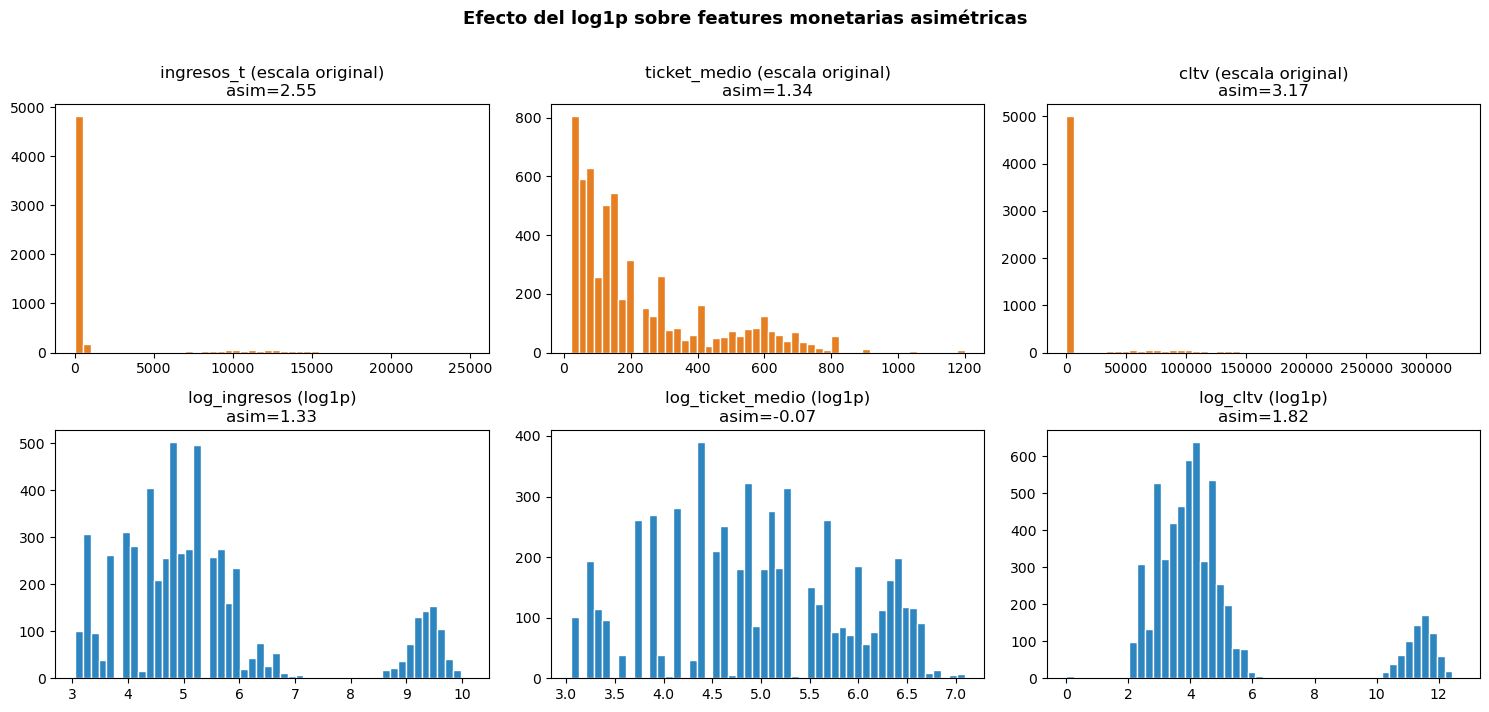

In [6]:
df_aug['log_ingresos']     = np.log1p(df_aug['ingresos_t'])
df_aug['log_ticket_medio'] = np.log1p(df_aug['ticket_medio'])
df_aug['log_cltv']         = np.log1p(df_aug['cltv'])

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, (col_orig, col_log) in enumerate([
    ('ingresos_t',   'log_ingresos'),
    ('ticket_medio', 'log_ticket_medio'),
    ('cltv',         'log_cltv'),
]):
    axes[0,i].hist(df_aug[col_orig], bins=50, color='#E67E22', edgecolor='white')
    axes[0,i].set_title(f'{col_orig} (escala original)\nasim={df_aug[col_orig].skew():.2f}')
    axes[1,i].hist(df_aug[col_log], bins=50, color='#2E86C1', edgecolor='white')
    axes[1,i].set_title(f'{col_log} (log1p)\nasim={df_aug[col_log].skew():.2f}')

plt.suptitle('Efecto del log1p sobre features monetarias asimétricas',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graficos/04b_log_transforms.png', dpi=130, bbox_inches='tight')
plt.show()
plt.close()

---
## 5. Comparativa de varianza efectiva (antes vs después)

Métrica `coeficiente de variación` (std / mean) para comprobar que las nuevas features tienen poder discriminante real.

In [7]:
feats_antes = ['ingresos_t', 'margen_t', 'frecuencia_t', 'ticket_medio', 'tasa_devolucion']
feats_despues = ['log_ingresos', 'num_ventas', 'dias_sin_compra', 'customer_age_days',
                  'n_productos_distintos', 'n_tiendas_distintas', 'n_categorias_distintas',
                  'lineas_por_venta', 'log_ticket_medio', 'tasa_devolucion']

def resumen(df, feats, etiqueta):
    rows = []
    for f in feats:
        s = df[f]
        rows.append({
            'feature': f,
            'mean':    round(s.mean(), 3),
            'std':     round(s.std(), 3),
            'CV':      round(s.std() / (abs(s.mean())+1e-9), 3),
            'p25':     round(s.quantile(0.25), 3),
            'p50':     round(s.quantile(0.50), 3),
            'p75':     round(s.quantile(0.75), 3),
            'p25=p75': s.quantile(0.25) == s.quantile(0.75),
        })
    out = pd.DataFrame(rows)
    out.insert(0, 'set', etiqueta)
    return out

tabla = pd.concat([resumen(df_aug, feats_antes,   'Antes'),
                    resumen(df_aug, feats_despues, 'Después')])
print('Comparativa de varianza efectiva por feature:')
display(tabla)

print('\nFeatures con P25=P75 (sin varianza útil en el rango central):')
sin_var = tabla[tabla['p25=p75']]['feature'].tolist()
print(f'  {sin_var}')
print(f'\n→ El nuevo set evita las features colapsadas y añade dimensionalidad real.')

Comparativa de varianza efectiva por feature:


,set,feature,mean,std,CV,p25,p50,p75,p25=p75
0,Antes,ingresos_t,1683.248,4089.972,2.430,79.800,149.900,299.990,False
1,Antes,margen_t,0.399,0.014,0.035,0.400,0.400,0.400,False
2,Antes,frecuencia_t,0.053,0.101,1.902,0.015,0.015,0.015,True
3,Antes,ticket_medio,221.085,205.220,0.928,79.800,149.900,299.990,False
4,Antes,tasa_devolucion,0.083,0.265,3.196,0.000,0.000,0.000,True
0,Después,log_ingresos,5.357,1.741,0.325,4.392,5.017,5.707,False
1,Después,num_ventas,3.478,6.586,1.893,1.000,1.000,1.000,True
2,Después,dias_sin_compra,673.457,601.069,0.893,92.000,421.000,1299.750,False
3,Después,customer_age_days,1993.614,57.398,0.029,1998.000,1998.000,1998.000,True
4,Después,n_productos_distintos,4.944,10.340,2.091,1.000,1.000,1.000,True



Features con P25=P75 (sin varianza útil en el rango central):
  ['frecuencia_t', 'tasa_devolucion', 'num_ventas', 'customer_age_days', 'n_productos_distintos', 'n_tiendas_distintas', 'n_categorias_distintas', 'lineas_por_venta', 'tasa_devolucion']

→ El nuevo set evita las features colapsadas y añade dimensionalidad real.


---
## 6. Guardar el CSV enriquecido

Sobrescribimos `cltv_resultados.csv` para que `05_pca_clustering.ipynb` use directamente el feature set nuevo, sin tocar al dashboard (que sigue funcionando con todas las columnas presentes).

In [8]:
df_aug.to_csv('cltv_resultados.csv', index=False)
print(f'cltv_resultados.csv actualizado.')
print(f'  Filas:    {len(df_aug):,}')
print(f'  Columnas: {len(df_aug.columns)}')
print(f'\nNuevas columnas añadidas:')
for c in feats + ['log_ingresos', 'log_ticket_medio', 'log_cltv']:
    print(f'  · {c}')

cltv_resultados.csv actualizado.
  Filas:    5,750
  Columnas: 31

Nuevas columnas añadidas:
  · n_productos_distintos
  · n_tiendas_distintas
  · n_categorias_distintas
  · lineas_por_venta
  · log_ingresos
  · log_ticket_medio
  · log_cltv


---
## Conclusión

Tras este enriquecimiento, `cltv_resultados.csv` contiene:

- **Features originales** (mantienen el cálculo CLTV intacto)
- **4 features de diversidad** desde el DWH (`n_productos_distintos`, `n_tiendas_distintas`, `n_categorias_distintas`, `lineas_por_venta`)
- **3 transformaciones logarítmicas** para reducir asimetría (`log_ingresos`, `log_ticket_medio`, `log_cltv`)

El siguiente notebook (`05_pca_clustering.ipynb`) usará el nuevo feature set y producirá clusters realmente diferenciados en múltiples dimensiones del comportamiento del cliente.